# Lección 1 – Fundamentos del Aprendizaje No Supervisado

## 1. Contexto del problema

1. Estamos trabajando para una consultora (Retail Insights S.A.) que quiere entender mejor el comportamiento de sus clientes minoristas para personalizar campañas de marketing.
2. Disponemos de datos de clientes en archivos `Train.csv` y `Test.csv`.
3. El objetivo global del módulo es construir un segmentador de clientes usando aprendizaje de máquina no supervisado.

## 2. ¿Qué es aprendizaje supervisado?

1. En el aprendizaje supervisado tenemos variables de entrada y una etiqueta conocida.
2. El modelo aprende una función que, dadas las características del cliente, predice su etiqueta correcta.
3. La clave es que las etiquetas ya están disponibles durante el entrenamiento.

## 3. ¿Qué es aprendizaje no supervisado?

1. En el aprendizaje no supervisado solo tenemos las variables de entrada, sin etiquetas.
2. El objetivo es descubrir estructura oculta en los datos: patrones, grupos o relaciones.
3. Para nuestro caso, significa dejar que los algoritmos descubran segmentos de clientes sin definirlos previamente.

## 4. Diferencias clave entre aprendizaje supervisado y no supervisado

1. Disponibilidad de etiquetas: en supervisado sí, en no supervisado no.
2. Objetivo: supervisado predice etiquetas, no supervisado descubre estructura.
3. Evaluación: supervisado usa métricas respecto de etiquetas reales; no supervisado usa métricas internas y análisis cualitativo.

## 5. Principales tareas del aprendizaje no supervisado

### 5.1 Clusterización

1. Agrupar observaciones de forma que dentro de cada grupo sean similares y distintos entre grupos.
2. En este proyecto, se usa para dividir clientes en segmentos con características similares.

### 5.2 Reducción de dimensionalidad

1. Transformar muchas variables en menos variables nuevas manteniendo la mayor parte de la información.
2. Técnicas clave: PCA y t-SNE.

### 5.3 Reglas de asociación

1. Encontrar patrones del tipo "si ocurre X, es probable que ocurra Y".
2. Se usa en análisis de cestas de compra.

## 6. Clasificación de técnicas por tipo

| Tipo de tarea                | Técnicas típicas                                      |
|-----------------------------|-------------------------------------------------------|
| Clusterización              | K-Means, DBSCAN, agrupamiento jerárquico             |
| Reducción de dimensionalidad| PCA, t-SNE                                            |
| Reglas de asociación        | Apriori, FP-Growth                                    |

## 7. Casos reales de aplicación

1. Segmentación de clientes en retail.
2. Detección de anomalías en transacciones.
3. Agrupación de documentos o noticias.
4. Segmentación de imágenes o señales.


# Lección 2 – Técnicas de Clusterización

## 1. ¿Qué es la clusterización?

1. La clusterización es una técnica de aprendizaje no supervisado que agrupa observaciones en grupos (clústeres) de manera que los elementos de un mismo grupo sean similares entre sí y distintos de los de otros grupos.
2. En el contexto de este proyecto, cada observación es un cliente y cada clúster representa un segmento de clientes con características similares.
3. El algoritmo no conoce de antemano qué grupos existen ni cuántos segmentos son “correctos”; los descubre a partir de los datos.

## 2. Escenarios donde se aplica clusterización

1. Segmentación de clientes.
2. Detección de patrones en consumo.
3. Agrupación de documentos.
4. Análisis de imágenes o señales.

## 3. Algoritmos que usaremos

1. K-Means.
2. DBSCAN.
3. Agrupamiento jerárquico.

## 4. K-Means

- Divide los datos en un número fijo de clústeres `k`.
- Ventajas: sencillo, escala bien.
- Desventajas: requiere elegir `k`, sensible a outliers y escala.

## 5. DBSCAN

- Agrupa puntos densos y marca ruido.
- Ventajas: detecta formas arbitrarias, detecta ruido.
- Desventajas: elección de eps y min_samples puede ser difícil.

## 6. Agrupamiento jerárquico

- Construye una jerarquía de clústeres (dendrograma).
- Ventajas: no requiere k inicial, da estructura en niveles.
- Desventajas: costoso en datasets grandes.

## 7. Tabla comparativa

| Característica                  | K-Means                             | DBSCAN                                      | Jerárquico                                   |
|---------------------------------|-------------------------------------|---------------------------------------------|----------------------------------------------|
| Necesita número de clústeres k  | Sí                                  | No                                          | No (se decide al cortar el dendrograma)      |
| Forma de los clústeres          | Esféricos / similares en tamaño     | Cualquier forma definida por la densidad    | Flexible, depende del criterio de enlace     |
| Manejo de ruido/outliers        | Sensible al ruido                   | Detecta ruido explícitamente                | Puede verse afectado por outliers            |
| Escalabilidad                   | Buena en grandes datasets           | Moderada                                    | Limitada en datasets muy grandes             |
| Interpretación                  | Centroides claros por clúster       | Clústeres basados en densidad y vecinos     | Estructura jerárquica visual (dendrograma)   |


# Lección 3 – Preprocesamiento, PCA y t-SNE

En esta lección preparamos los datos de clientes para aplicar técnicas de reducción de dimensionalidad y luego clusterización.


## 1. Carga de datos

Importamos las librerías necesarias y cargamos los archivos `Train.csv` y `Test.csv`.


In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Carga de datos
train = pd.read_csv('Train.csv')
test = pd.read_csv('Test.csv')

train.shape, test.shape

((8068, 11), (2627, 11))

## 2. Vista rápida de los datos

Revisamos las primeras filas del conjunto de entrenamiento para entender la estructura de las columnas.


In [74]:
train.head()


,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


## 3. Tipos de datos y valores nulos

Revisamos tipos de datos y valores nulos para decidir el preprocesamiento.


In [75]:
train.dtypes, train.isnull().sum()

(ID                   int64
 Gender              object
 Ever_Married        object
 Age                  int64
 Graduated           object
 Profession          object
 Work_Experience    float64
 Spending_Score      object
 Family_Size        float64
 Var_1               object
 Segmentation        object
 dtype: object,
 ID                   0
 Gender               0
 Ever_Married       140
 Age                  0
 Graduated           78
 Profession         124
 Work_Experience    829
 Spending_Score       0
 Family_Size        335
 Var_1               76
 Segmentation         0
 dtype: int64)

## 4. Definición de columnas numéricas y categóricas

Separamos las columnas en numéricas y categóricas según su tipo de dato.


In [76]:
numeric_features = []
categorical_features = []

for col, dtype in train.dtypes.items():
    if dtype in ['int64', 'float64']:
        numeric_features.append(col)
    else:
        categorical_features.append(col)

numeric_features, categorical_features

(['ID', 'Age', 'Work_Experience', 'Family_Size'],
 ['Gender',
  'Ever_Married',
  'Graduated',
  'Profession',
  'Spending_Score',
  'Var_1',
  'Segmentation'])

## 5. Pipeline de preprocesamiento

Creamos un pipeline para imputar y escalar variables numéricas, e imputar y codificar variables categóricas.


In [77]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

X_train_prep = preprocessor.fit_transform(train)
X_train_prep.shape


(8068, 33)

## 6. Aplicación de PCA

Analizamos la varianza explicada por PCA y generamos una proyección en 2D.


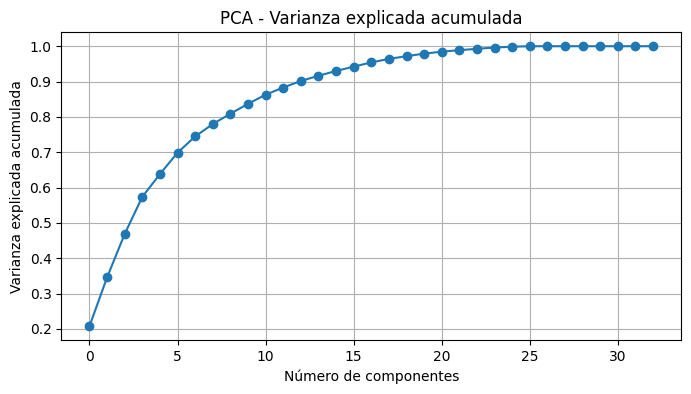

In [78]:
X_for_pca = X_train_prep.toarray() if hasattr(X_train_prep, 'toarray') else X_train_prep

pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_for_pca)

explained_variance_ratio = pca_full.explained_variance_ratio_

plt.figure(figsize=(8,4))
plt.plot(np.cumsum(explained_variance_ratio), marker='o')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.title('PCA - Varianza explicada acumulada')
plt.grid(True)
plt.show()

### 6.1 PCA con 2 componentes

Generamos una versión de 2 componentes principales para visualizar.


In [79]:
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_for_pca)

X_pca_2[:5]

array([[-2.13083365, -0.75359718],
       [ 0.20622766, -0.36053353],
       [ 1.84301363,  0.23787553],
       [ 2.0493703 , -0.31981119],
       [-0.32257446, -1.43155727]])

## 7. Aplicación de t-SNE

Calculamos una representación en 2D usando t-SNE sobre una muestra de los datos si es necesario.


In [80]:
from sklearn.utils import resample

n_samples = 2000
if X_train_prep.shape[0] > n_samples:
    X_sample = resample(X_train_prep, n_samples=n_samples, random_state=42)
else:
    X_sample = X_train_prep

X_for_tsne = X_sample.toarray() if hasattr(X_sample, 'toarray') else X_sample

tsne = TSNE(n_components=2, random_state=42, perplexity=30, learning_rate=200)
X_tsne_2 = tsne.fit_transform(X_for_tsne)

X_tsne_2[:5]

array([[-61.09869  ,  -1.3418514],
       [-13.66431  ,  10.552035 ],
       [-20.082146 , -17.593185 ],
       [-65.17973  ,   9.34334  ],
       [ -2.157575 , -19.466736 ]], dtype=float32)

# Lección 4 – Clusterización con K-Means, DBSCAN y Agrupamiento Jerárquico

Aplicamos algoritmos de clusterización sobre los datos preprocesados y analizamos visualmente los clústeres.


## 1. Preparación: uso de datos preprocesados

Reutilizamos `X_train_prep` y su versión densa para clusterizar.


In [81]:
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score

X_for_clust = X_train_prep.toarray() if hasattr(X_train_prep, 'toarray') else X_train_prep
X_for_clust.shape

(8068, 33)

## 2. K-Means: método del codo

Probamos distintos valores de `k` y calculamos la inercia para aplicar el método del codo.


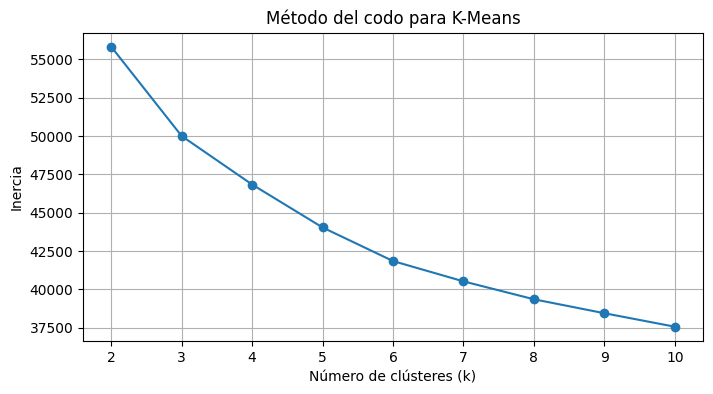

[55833.59489238804,
 50004.73788366191,
 46839.090208347116,
 44035.66020352755,
 41843.03813982998,
 40516.943269936644,
 39347.10556420182,
 38437.36954315409,
 37556.46488120106]

In [82]:
inertias = []
ks = range(2, 11)

for k in ks:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_for_clust)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8,4))
plt.plot(ks, inertias, marker='o')
plt.xlabel('Número de clústeres (k)')
plt.ylabel('Inercia')
plt.title('Método del codo para K-Means')
plt.grid(True)
plt.show()

inertias

## 3. K-Means: coeficiente de silueta

Calculamos el coeficiente de silueta para los distintos `k`.


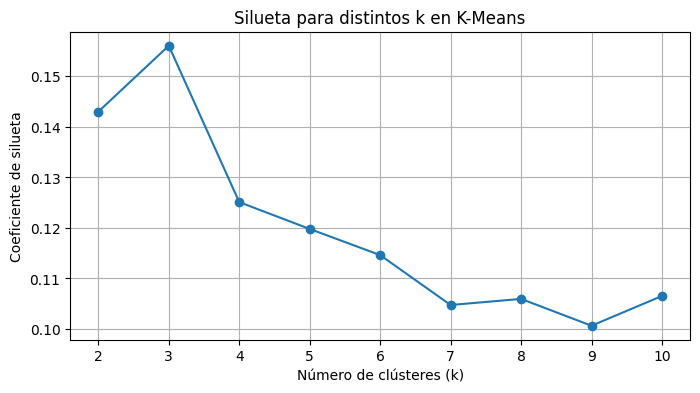

[0.14301297082438846,
 0.15606540039010403,
 0.1251120495805612,
 0.11979886434050971,
 0.11462400545205242,
 0.10474688481421254,
 0.10595628121618293,
 0.10064596769774481,
 0.10653350008937386]

In [83]:
silhouettes = []
ks = range(2, 11)

for k in ks:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_for_clust)
    score = silhouette_score(X_for_clust, labels)
    silhouettes.append(score)

plt.figure(figsize=(8,4))
plt.plot(ks, silhouettes, marker='o')
plt.xlabel('Número de clústeres (k)')
plt.ylabel('Coeficiente de silueta')
plt.title('Silueta para distintos k en K-Means')
plt.grid(True)
plt.show()

silhouettes

## 4. K-Means: ajuste final y visualización

Elegimos un `k` adecuado y visualizamos los clústeres en el plano PCA.


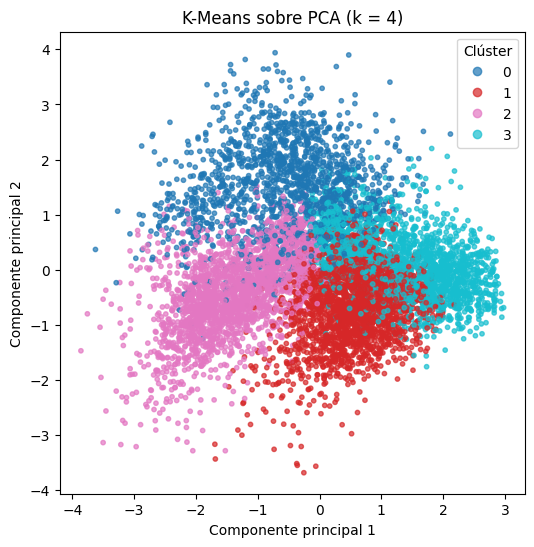

0.1251120495805612

In [84]:
best_k = 4  # ajustar según los gráficos

kmeans_final = KMeans(n_clusters=best_k, random_state=42)
labels_kmeans = kmeans_final.fit_predict(X_for_clust)

plt.figure(figsize=(6,6))
scatter = plt.scatter(X_pca_2[:,0], X_pca_2[:,1], c=labels_kmeans, cmap='tab10', s=10, alpha=0.7)
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.title('K-Means sobre PCA (k = %d)' % best_k)
plt.legend(*scatter.legend_elements(), title='Clúster')
plt.show()

silhouette_kmeans = silhouette_score(X_for_clust, labels_kmeans)
silhouette_kmeans

## 5. DBSCAN: clusterización por densidad

Aplicamos DBSCAN, observamos número de clústeres y ruido, y visualizamos en PCA 2D.


In [85]:
eps = 0.5
min_samples = 5

dbscan = DBSCAN(eps=eps, min_samples=min_samples)
labels_dbscan = dbscan.fit_predict(X_for_clust)

unique_labels_db = np.unique(labels_dbscan)
unique_labels_db, np.bincount(labels_dbscan + 1)

(array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
        16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32,
        33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49,
        50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66,
        67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77]),
 array([7282,    5,   13,   31,   37,   79,   21,   22,    8,    9,    8,
           7,    5,    5,    7,   20,    8,    7,    7,   34,    7,   10,
           6,   13,    9,   37,   12,   11,    8,    8,    8,    8,    6,
          14,    8,    6,    5,    7,   16,    6,    9,    5,   13,    8,
          13,    8,    5,    8,   11,   10,    5,    7,    6,    5,    5,
           5,    5,    6,    9,    5,    6,    5,    7,    5,    8,    5,
           5,    5,    5,    5,    2,    7,    5,    5,    5,    5,    5,
           5,    5]))

### 5.1 Visualización de DBSCAN en PCA 2D


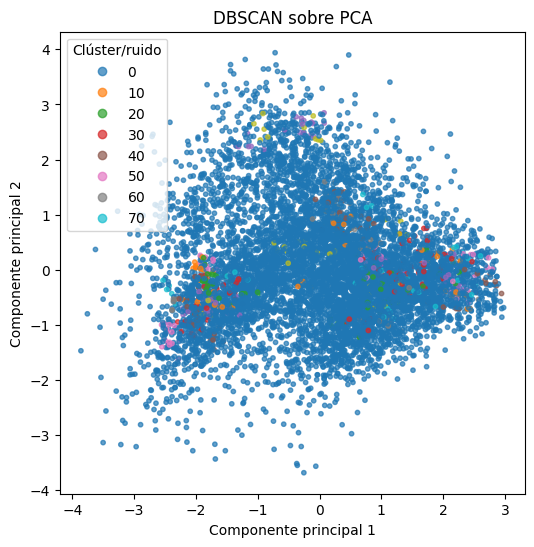

0.41883037404380236

In [86]:
plt.figure(figsize=(6,6))
scatter = plt.scatter(X_pca_2[:,0], X_pca_2[:,1], c=labels_dbscan, cmap='tab10', s=10, alpha=0.7)
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.title('DBSCAN sobre PCA')
plt.legend(*scatter.legend_elements(), title='Clúster/ruido')
plt.show()

labels_unique = set(labels_dbscan)
labels_unique.discard(-1)
if len(labels_unique) > 1:
    mask = labels_dbscan != -1
    silhouette_dbscan = silhouette_score(X_for_clust[mask], labels_dbscan[mask])
else:
    silhouette_dbscan = None
silhouette_dbscan

## 6. Agrupamiento jerárquico

Aplicamos agrupamiento jerárquico aglomerativo y visualizamos los clústeres.


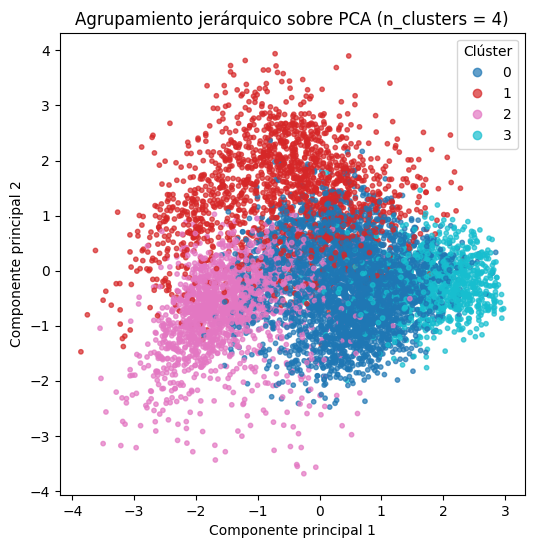

0.10271159603200981

In [87]:
n_clusters_hier = 4

agg = AgglomerativeClustering(n_clusters=n_clusters_hier)
labels_agg = agg.fit_predict(X_for_clust)

plt.figure(figsize=(6,6))
scatter = plt.scatter(X_pca_2[:,0], X_pca_2[:,1], c=labels_agg, cmap='tab10', s=10, alpha=0.7)
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.title('Agrupamiento jerárquico sobre PCA (n_clusters = %d)' % n_clusters_hier)
plt.legend(*scatter.legend_elements(), title='Clúster')
plt.show()

silhouette_agg = silhouette_score(X_for_clust, labels_agg)
silhouette_agg

# Lección 5 – Evaluación de Resultados e Informe Final

Comparamos las distintas segmentaciones, evaluamos su consistencia y preparamos material para el informe.


## 1. Tabla resumen de métricas

Construimos una tabla que compare, para cada algoritmo, el número de clústeres efectivos, el coeficiente de silueta y la cantidad de ruido.


In [88]:
# Número de clústeres efectivos
n_clusters_kmeans = len(np.unique(labels_kmeans))

labels_db_unique = np.unique(labels_dbscan)
n_clusters_dbscan = len(labels_db_unique[labels_db_unique != -1])
n_noise_dbscan = np.sum(labels_dbscan == -1)

n_clusters_agg = len(np.unique(labels_agg))

summary = pd.DataFrame({
    'Algoritmo': ['K-Means', 'DBSCAN', 'Jerárquico'],
    'N_clústeres_efectivos': [n_clusters_kmeans, n_clusters_dbscan, n_clusters_agg],
    'Silueta': [silhouette_kmeans, silhouette_dbscan, silhouette_agg],
    'N_ruido': [0, n_noise_dbscan, 0]
})

summary

,Algoritmo,N_clústeres_efectivos,Silueta,N_ruido
0,K-Means,4,0.125112,0
1,DBSCAN,78,0.418830,7282
2,Jerárquico,4,0.102712,0


## 2. Visualización comparativa en PCA 2D

Comparamos visualmente las segmentaciones de K-Means, DBSCAN y jerárquico.


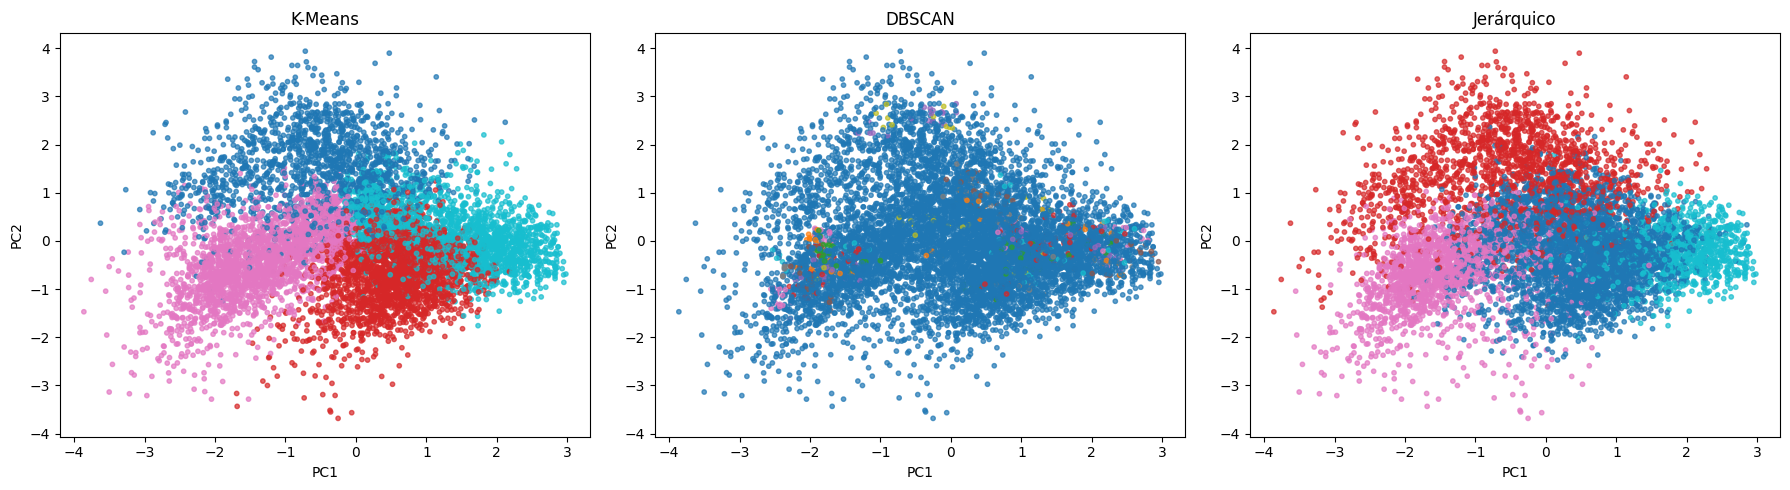

In [89]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(X_pca_2[:,0], X_pca_2[:,1], c=labels_kmeans, cmap='tab10', s=10, alpha=0.7)
axes[0].set_title('K-Means')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

axes[1].scatter(X_pca_2[:,0], X_pca_2[:,1], c=labels_dbscan, cmap='tab10', s=10, alpha=0.7)
axes[1].set_title('DBSCAN')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

axes[2].scatter(X_pca_2[:,0], X_pca_2[:,1], c=labels_agg, cmap='tab10', s=10, alpha=0.7)
axes[2].set_title('Jerárquico')
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')

plt.tight_layout()
plt.show()

## 3. Guardado de figuras para el informe

Guardamos algunas figuras clave (PCA + clústeres) como archivos `.png`.


In [90]:
import os
os.makedirs('figuras', exist_ok=True)

# K-Means
plt.figure(figsize=(6,6))
plt.scatter(X_pca_2[:,0], X_pca_2[:,1], c=labels_kmeans, cmap='tab10', s=10, alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-Means sobre PCA')
plt.savefig('figuras/kmeans_pca.png', dpi=300, bbox_inches='tight')
plt.close()

# DBSCAN
plt.figure(figsize=(6,6))
plt.scatter(X_pca_2[:,0], X_pca_2[:,1], c=labels_dbscan, cmap='tab10', s=10, alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('DBSCAN sobre PCA')
plt.savefig('figuras/dbscan_pca.png', dpi=300, bbox_inches='tight')
plt.close()

# Jerárquico
plt.figure(figsize=(6,6))
plt.scatter(X_pca_2[:,0], X_pca_2[:,1], c=labels_agg, cmap='tab10', s=10, alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Jerárquico sobre PCA')
plt.savefig('figuras/jerarquico_pca.png', dpi=300, bbox_inches='tight')
plt.close()

os.listdir('figuras')

['dbscan_pca.png', 'jerarquico_pca.png', 'kmeans_pca.png']